In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [28]:
df=pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [29]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [30]:
print(f"Dataset Information:\n{df.info()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [31]:
print(f'\n Statistical Summary :\n{df.describe()}')


 Statistical Summary :
                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.213481e-16 -2.406331e-15   
std    1.380247e+0

In [32]:
print(f'\nMissing Values :\n{df.isnull().sum() }')
print(f'\nTotal Missing Values : {df.isnull().sum().sum()} ')


Missing Values :
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Total Missing Values : 0 


In [33]:
print(f'\nDuplicate Values : {df.duplicated().sum()}')
class_counts = df['Class'].value_counts()


Duplicate Values : 1081


In [34]:
print(class_counts)

Class
0    284315
1       492
Name: count, dtype: int64


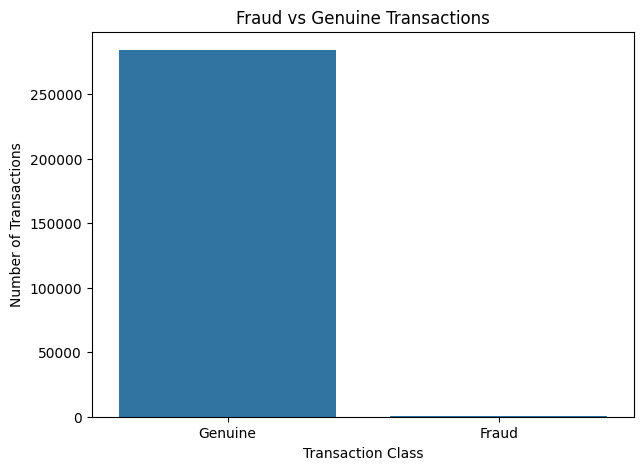

In [35]:
#fraud vs genuine distributions
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Class')

plt.title("Fraud vs Genuine Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

plt.xticks([0, 1], ['Genuine', 'Fraud'])

plt.show()

In [36]:
#percentage distributions
class_percentage = df['Class'].value_counts(normalize=True) * 100

print("Transaction Percentage:")
print(class_percentage)

Transaction Percentage:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [37]:
#transaction amount analysis
amount_stats = df.groupby('Class')['Amount'].describe()
display(amount_stats)

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


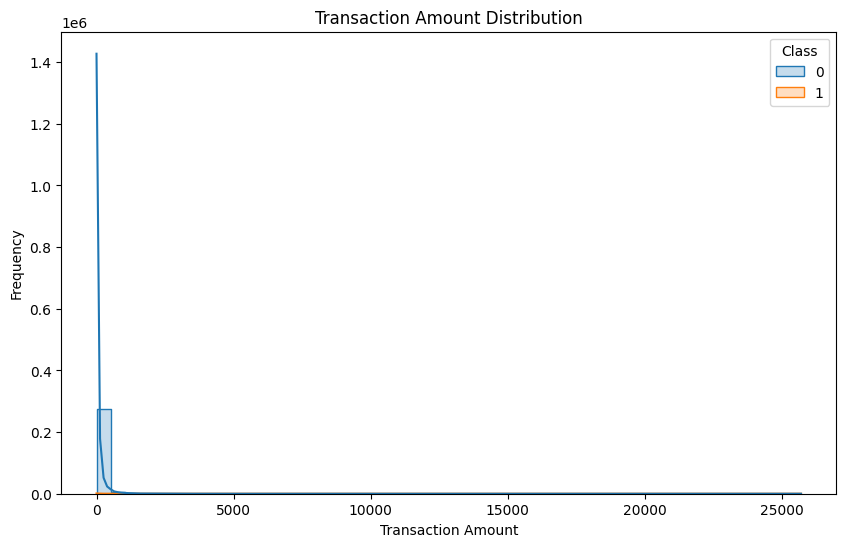

In [38]:
#genuine and fraudulent transaction amounts
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='Amount',
    hue='Class',
    bins=50,
    kde=True,
    element='step'
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

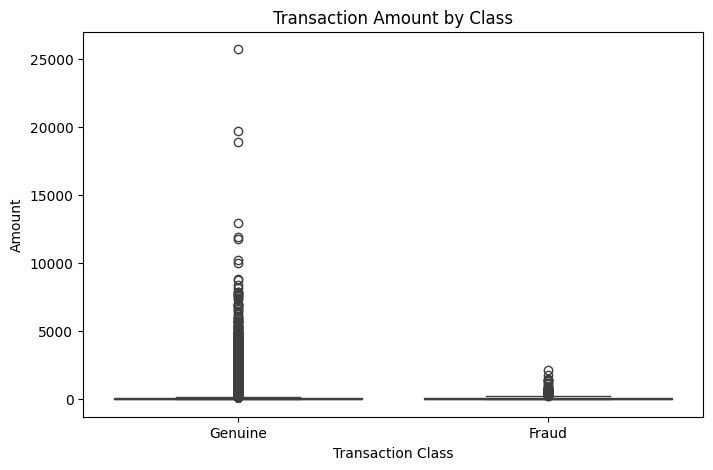

In [39]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Class',
    y='Amount'
)

plt.title("Transaction Amount by Class")
plt.xlabel("Transaction Class")
plt.ylabel("Amount")

plt.xticks([0, 1], ['Genuine', 'Fraud'])

plt.show()

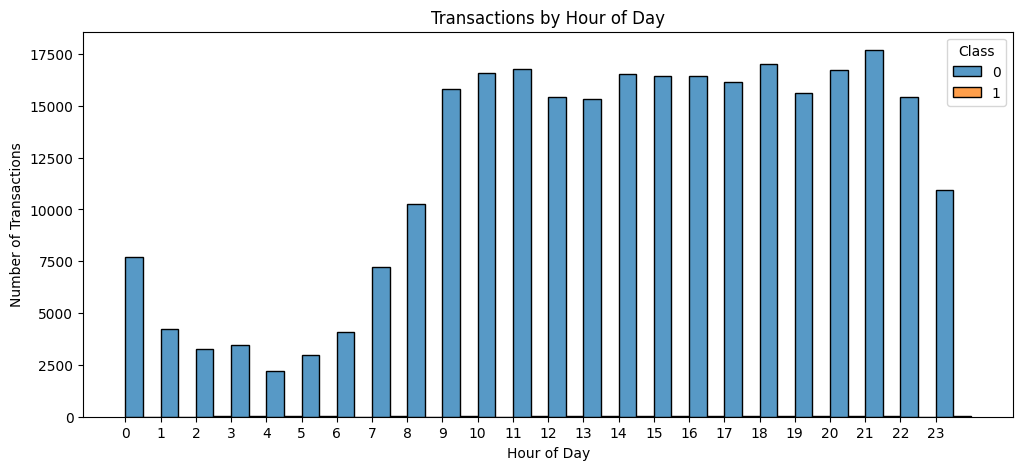

In [41]:
#transaction time analysis
df['Hour'] = (df['Time'] / 3600) % 24

plt.figure(figsize=(12, 5))

sns.histplot(
    data=df,
    x='Hour',
    hue='Class',
    bins=24,
    multiple='dodge'
)

plt.title("Transactions by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")
plt.xticks(range(0, 24))
plt.show()



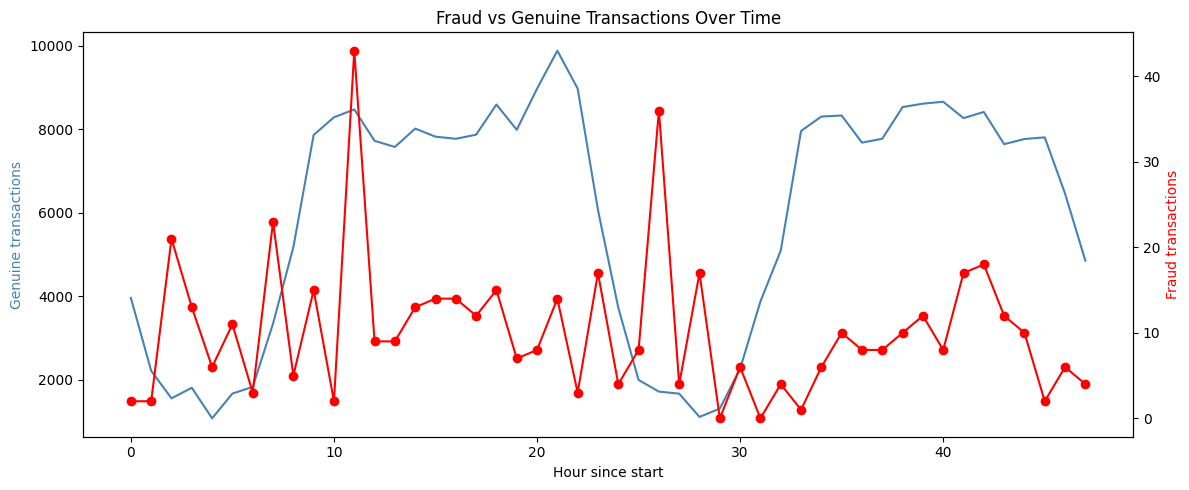

In [42]:
#fraud vs genuine overtime
df['Hour'] = (df['Time'] // 3600).astype(int)
counts = df.groupby(['Hour', 'Class']).size().unstack(fill_value=0)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(counts.index, counts[0], color='steelblue', label='Genuine')
ax1.set_xlabel("Hour since start")
ax1.set_ylabel("Genuine transactions", color='steelblue')

ax2 = ax1.twinx()
ax2.plot(counts.index, counts[1], color='red', marker='o', label='Fraud')
ax2.set_ylabel("Fraud transactions", color='red')

plt.title("Fraud vs Genuine Transactions Over Time")
fig.tight_layout()
plt.show()

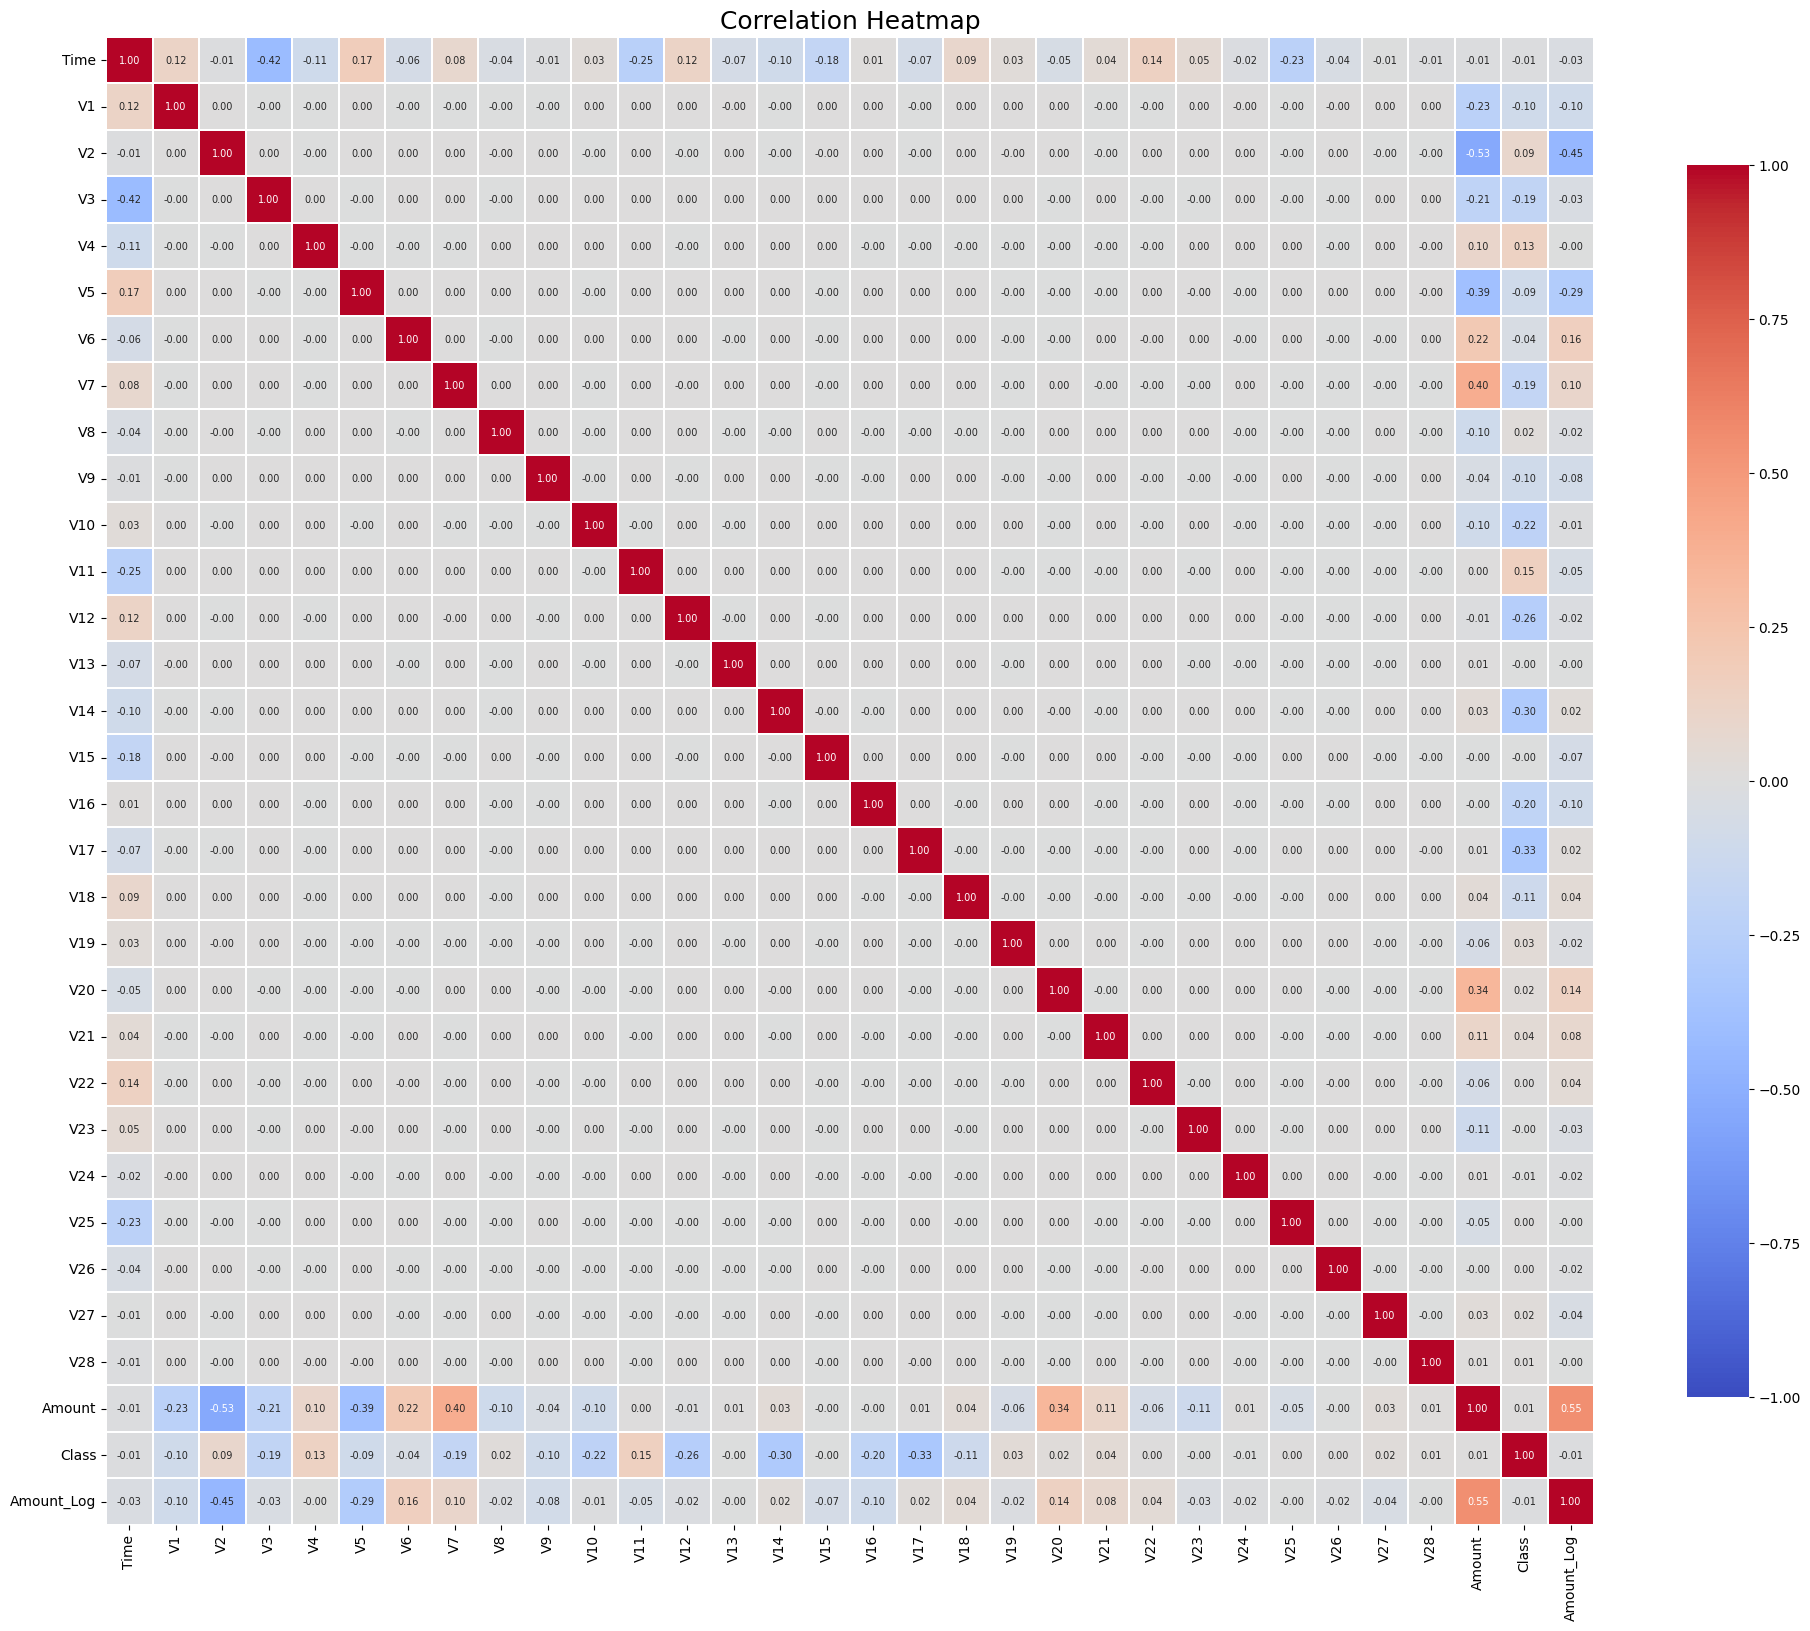

In [44]:
corr = df.drop(columns='Hour', errors='ignore').corr()

plt.figure(figsize=(24, 20))
sns.heatmap(corr, annot=True, fmt='.2f', annot_kws={'size': 7},
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.3, cbar_kws={'shrink': 0.8})
plt.title("Correlation Heatmap", fontsize=18)
plt.show()

In [45]:
corr_class = df.drop(columns='Hour', errors='ignore').corr()['Class'].drop('Class').sort_values(key=abs, ascending=False)
print(corr_class)

V17          -0.326481
V14          -0.302544
V12          -0.260593
V10          -0.216883
V16          -0.196539
V3           -0.192961
V7           -0.187257
V11           0.154876
V4            0.133447
V18          -0.111485
V1           -0.101347
V9           -0.097733
V5           -0.094974
V2            0.091289
V6           -0.043643
V21           0.040413
V19           0.034783
V20           0.020090
V8            0.019875
V27           0.017580
Time         -0.012323
V28           0.009536
Amount_Log   -0.008326
V24          -0.007221
Amount        0.005632
V13          -0.004570
V26           0.004455
V15          -0.004223
V25           0.003308
V23          -0.002685
V22           0.000805
Name: Class, dtype: float64


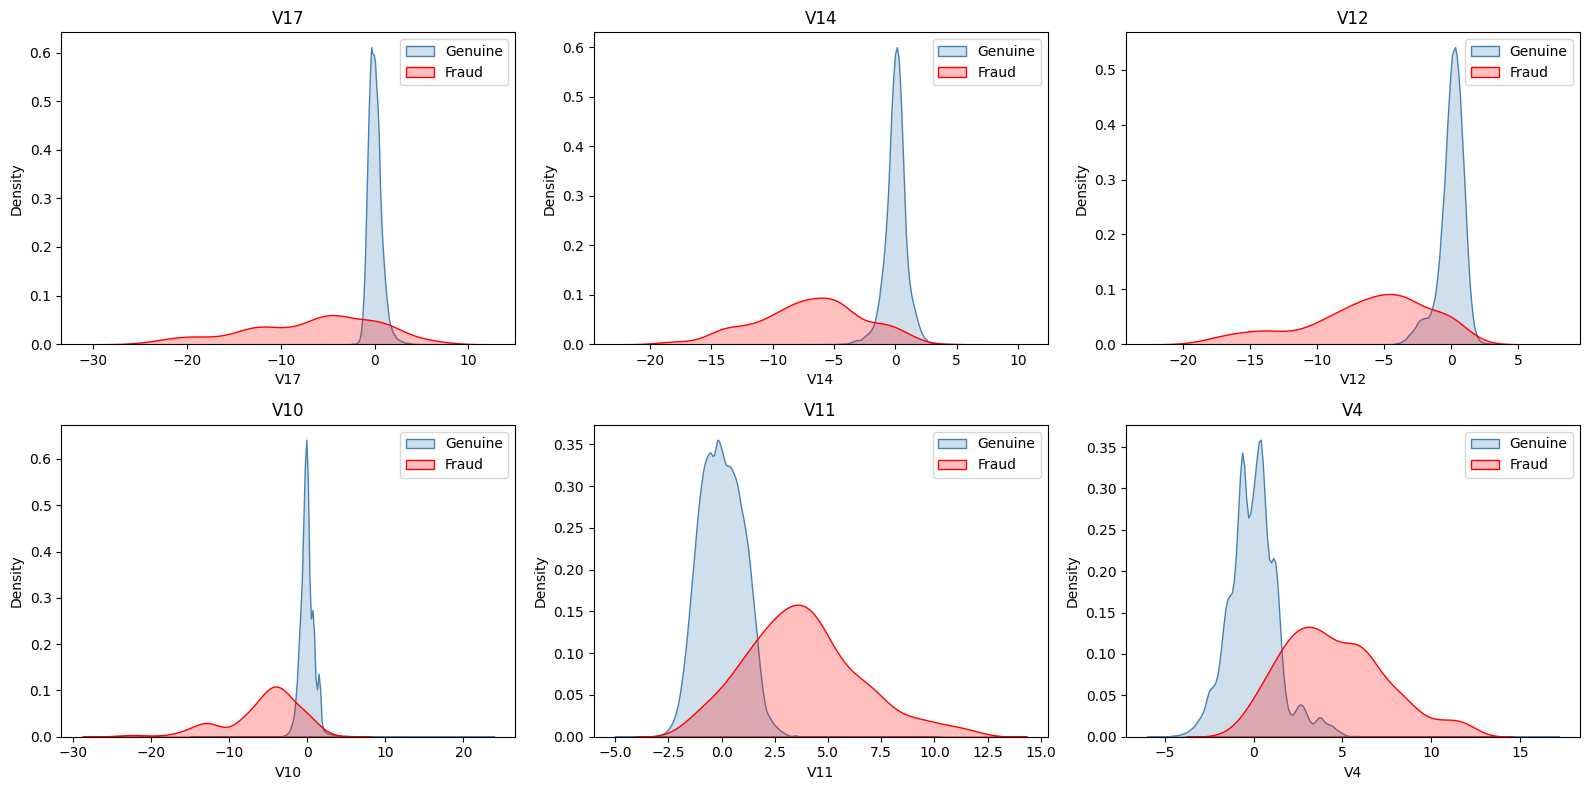

In [46]:
#Feature distributions (V17, V14, V12, V10 by class)
top = ['V17', 'V14', 'V12', 'V10', 'V11', 'V4']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel(), top):
    sns.kdeplot(data=df[df.Class == 0], x=col, ax=ax, label='Genuine', fill=True, color='steelblue', common_norm=False)
    sns.kdeplot(data=df[df.Class == 1], x=col, ax=ax, label='Fraud', fill=True, color='red', common_norm=False)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

In [47]:
df['HourOfDay'] = ((df['Time'] // 3600) % 24).astype(int)
rate_hod = df.groupby('HourOfDay')['Class'].mean() * 100
print(df.groupby('Class')['Amount'].agg(['mean', 'median']))
print((df[df.Class == 1].Amount < 1).mean() * 100, "% of fraud under 1")
print(rate_hod.sort_values(ascending=False).head(5))
print(df.groupby('Class')[['V17', 'V14', 'V12', 'V10']].median())

             mean  median
Class                    
0       88.291022   22.00
1      122.211321    9.25
13.821138211382115 % of fraud under 1
HourOfDay
2    1.712740
4    1.041195
3    0.486827
5    0.367893
7    0.317548
Name: Class, dtype: float64
            V17       V14       V12       V10
Class                                        
0     -0.064833  0.051947  0.141679 -0.091872
1     -5.302949 -6.729720 -5.502530 -4.578825


                Predicted Genuine  Predicted Fraud
Actual Genuine               0.00                5
Actual Fraud               122.21                0


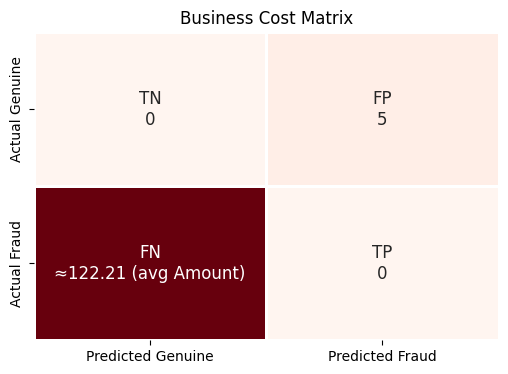


Cost if no fraud detection (miss all fraud): 60,127.97
Cost if every transaction is flagged: 1,421,575.00


In [48]:
FP_COST = 5  # ASSUMPTION: cost of reviewing one false alarm; change as needed

avg_fraud_amt = df.loc[df.Class == 1, 'Amount'].mean()
fraud_loss = df.loc[df.Class == 1, 'Amount'].sum()
n_genuine = (df.Class == 0).sum()

# Cost matrix (FN shown as the average fraud amount; actual FN cost = that transaction's Amount)
cost_matrix = pd.DataFrame(
    [[0, FP_COST],
     [avg_fraud_amt, 0]],
    index=['Actual Genuine', 'Actual Fraud'],
    columns=['Predicted Genuine', 'Predicted Fraud']
)
print(cost_matrix.round(2))

plt.figure(figsize=(6, 4))
labels = np.array([['TN\n0', f'FP\n{FP_COST}'],
                   [f'FN\n≈{avg_fraud_amt:.2f} (avg Amount)', 'TP\n0']])
sns.heatmap(cost_matrix, annot=labels, fmt='', cmap='Reds', cbar=False,
            linewidths=2, linecolor='white', annot_kws={'size': 12})
plt.title("Business Cost Matrix")
plt.show()

# Benchmarks
print(f"\nCost if no fraud detection (miss all fraud): {fraud_loss:,.2f}")
print(f"Cost if every transaction is flagged: {FP_COST * n_genuine:,.2f}")

findings

1.severe class imbalance: fraud is only 492 of 2,84,807 transactions which is about (0.17%) so accuray is a misleading metric so the model needs PR-AUC ,recall,f1
2.fraud amounts are typically small-the median fraud amount is 9.25 vs 22.00 for genuine ,and 13.8% of fraud transactions are under 1 unit
--the fraud mean is higher 122.21 vs 88.29 of genuine
--the maximum fraud amount is 2,125.87 vs 25,961.16 for genuine,so it indicates that fraud is done on only small amounts
3.fraud is concntrated on the early hours -the fraud rate peaks at hour 2 at 1.71%
--the top five hours are 2,4,3,5and 7

4.Several V-features separate fraud from genuine clearly. The median V17 is -5.30 for fraud vs -0.06 for genuine, and V14 is -6.73 vs 0.05. V12 and V10 show the same shift, and V11 and V4 shift positive. These match the strongest correlations with Class (V17 -0.33, V14 -0.30, V12 -0.26, V10 -0.22).

5.no single feature predicts fraud well .the strongest corelation with class is only (-0.33) ,and amount (0.006) and time (-0.012) are near zero
6.fraud shows up as a combined shift across several V-features, so a multivariate model such as Random Forest or XGBoost is justified


Cost Matrix Analysis

Cost assumptions: FP = 5 per transaction, FN = transaction Amount, TP = TN = 0.
Baseline 1 (no detection): total cost = 60,127.97 (sum of Amount over 492 fraud transactions).
Baseline 2 (flag all): total cost = 1,421,575.00 (5 × 284,315 genuine transactions), about 23.6x Baseline 1

neither baseline is viable. A deployable model must have total cost (sum of FN amounts + 5 × FP count) below 60,127.97.
